CONDITIONALDCGan-cifar10

In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
from tqdm.notebook import tqdm

In [2]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch version: 2.9.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


In [ ]:
# hyperparameters
dataroot = "/content/cifar10"
workers = 2
batch_size = 128
image_size = 32
nc = 3
nz = 100
ngf = 64
ndf = 64
num_epochs = 50
lr = 0.0002
beta1 = 0.5
ngpu = 1
manualSeed = 999


print(f"Random Seed: {manualSeed}")
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.cuda.manual_seed_all(manualSeed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Random Seed: 999
Using device: cuda:0


In [ ]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
dataset = datasets.CIFAR10(
    root=dataroot,              # Where to save the data (e.g., "./data")
    train=True,         # Use the "training" set (50,000 images)
    download=True,               # If the data isn't in 'root', download it from the internet
    transform=transform        # Apply the Resize/Normalize steps we just
)
dataloader = torch.utils.data.DataLoader(
    dataset,                   # Use the CIFAR10 map we just created
    batch_size=batch_size,       # How many images to show the GAN at once (e.g. 128)
    shuffle=True,                   # Mix the images up every epoch
    num_workers=workers)           # How many CPU cores to use for loading images 2
print(f"Dataset loaded: {len(dataset)} images")


Dataset loaded: 50000 images


d:\openCV\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
num_classes = len(dataset.classes)
print(f"Number of classes in CIFAR-10 dataset: {num_classes}")

Number of classes in CIFAR-10 dataset: 10


Labels for the first 8 images: [0, 4, 9, 2, 9, 6, 3, 2]


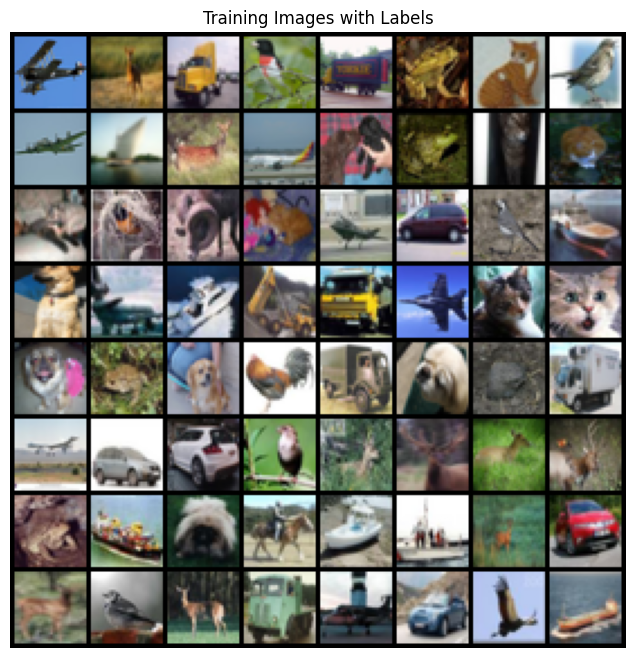

In [ ]:
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))              # It makes it an 8x8 inch square,         
plt.axis("off")                         # hides the X/Y graph axes
plt.title("Training Images with Labels")    # Title for the image
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
print(f"Labels for the first 8 images: {real_batch[1][:8].tolist()}")

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__ # Corrected line: changed '__name_' to '__name__'
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:        
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

#This keeps the data centered and scaled properly
# as it flows through the deep layers of your GAN.
   

In [ ]:
def one_hot_encode(labels, num_classes):

    # Converts a batch of integer labels into one-hot encoded tensors.

    # Create a tensor of zeros with shape (batch_size, num_classes)
    one_hot = torch.zeros(labels.size(0), num_classes, device=labels.device)
    # Scatter ones at the positions indicated by the labels
    one_hot.scatter_(1, labels.unsqueeze(1), 1)
    return one_hot

print("One-hot encoding function defined.")

One-hot encoding function defined.


In [9]:
import torch

# Assuming num_classes is already defined (e.g., num_classes = 10)
# And dataset.classes contains the class names

class_names = dataset.classes # Get the class names from the loaded dataset

print(f"Generating one-hot encoding vectors for {num_classes} classes:\n")

for i in range(num_classes):
    # Create a tensor of zeros with the size of num_classes
    one_hot_vector = torch.zeros(num_classes)

    # Set the element at the current class index to 1
    one_hot_vector[i] = 1

    print(f"Class {i} ({class_names[i]}): {one_hot_vector}")

Generating one-hot encoding vectors for 10 classes:

Class 0 (airplane): tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Class 1 (automobile): tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
Class 2 (bird): tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
Class 3 (cat): tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])
Class 4 (deer): tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
Class 5 (dog): tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
Class 6 (frog): tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])
Class 7 (horse): tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])
Class 8 (ship): tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])
Class 9 (truck): tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)     # the Discriminator doesn't just look at the image; it also looks at the label 

        self.net = nn.Sequential(
            # input is (nc + num_classes) x image_size x image_size
            nn.Conv2d(nc + num_classes, ndf, 3, 1, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()     #  Output: final layer pushes the answer between 0 (Fake) and 1 (Real).
        )

    def forward(self, input, labels):
        # Input is (nc) x image_size x image_size
        # Labels are batch_size The .view(-1, num_classes, 1, 1) shapes it so it can be layered onto an image.
        label_embedding = self.label_emb(labels).view(-1, num_classes, 1, 1)
        # Expand label embedding to match image dimensions for concatenation
        label_embedding = label_embedding.repeat(1, 1, input.size(2), input.size(3))
        x = torch.cat([input, label_embedding], dim=1)
        return self.net(x).view(-1, 1).squeeze(1)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz + num_classes, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 3, 1, 1, bias=False),
            nn.Tanh()  # Output: final layer pushes the answer between -1 and 1.Generator’s output must match the Discriminator’s expectations!
        )

    def forward(self, noise, labels):
        label_embedding = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, label_embedding], dim=1)
        return self.net(x)


In [ ]:
# Create the Generator
netG = Generator().to(device)
netG.apply(weights_init)     # Apply the weights_init function to randomly initialize all weights
print(netG)                 # to mean=0, stdev=0.2.

# Create the Discriminator
netD = Discriminator().to(device)

# Apply the weights_init function to randomly initialize all weights
# to mean=0, stdev=0.2.
netD.apply(weights_init)

# Print the model
print(netD)

# Initialize BCELoss function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
# the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

Generator(
  (label_emb): Embedding(10, 10)
  (net): Sequential(
    (0): ConvTranspose2d(110, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (label_emb): Embedding(10, 10)
  (net): Sequential(
    (0): Conv2d(13, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slo

In [13]:
criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.0
fake_label = 0.0
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
print("Training:")


Training:


Fixed labels for visualization: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3]
Starting Training Loop...


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

[0/50][0/391] Loss_D: 1.7054 Loss_G: 2.4603 D(x): 0.4776 D(G(z)): 0.4310 / 0.4561
[0/50][50/391] Loss_D: 0.7552 Loss_G: 2.4654 D(x): 0.7276 D(G(z)): 0.1826 / 0.1490
[0/50][100/391] Loss_D: 1.1266 Loss_G: 2.5817 D(x): 0.7795 D(G(z)): 0.4834 / 0.1044
[0/50][150/391] Loss_D: 0.6991 Loss_G: 3.6720 D(x): 0.7967 D(G(z)): 0.3166 / 0.0303
[0/50][200/391] Loss_D: 0.4456 Loss_G: 4.1082 D(x): 0.8058 D(G(z)): 0.1476 / 0.0211
[0/50][250/391] Loss_D: 0.9030 Loss_G: 2.5660 D(x): 0.7591 D(G(z)): 0.4347 / 0.0901
[0/50][300/391] Loss_D: 0.9646 Loss_G: 1.6194 D(x): 0.6699 D(G(z)): 0.3514 / 0.2403
[0/50][350/391] Loss_D: 1.6428 Loss_G: 1.8154 D(x): 0.5658 D(G(z)): 0.5867 / 0.1999
[1/50][0/391] Loss_D: 1.1938 Loss_G: 1.4105 D(x): 0.6150 D(G(z)): 0.4250 / 0.2879
[1/50][50/391] Loss_D: 0.9368 Loss_G: 1.7858 D(x): 0.6824 D(G(z)): 0.3712 / 0.2038
[1/50][100/391] Loss_D: 1.2272 Loss_G: 1.2161 D(x): 0.5367 D(G(z)): 0.3541 / 0.3420
[1/50][150/391] Loss_D: 1.2402 Loss_G: 1.4745 D(x): 0.5470 D(G(z)): 0.3936 / 0.271

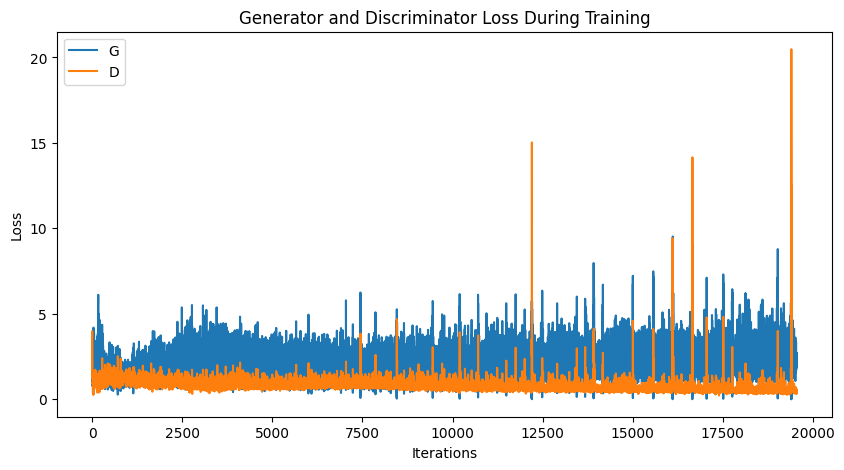

Animation size has reached 21443976 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Generating final images for each class...


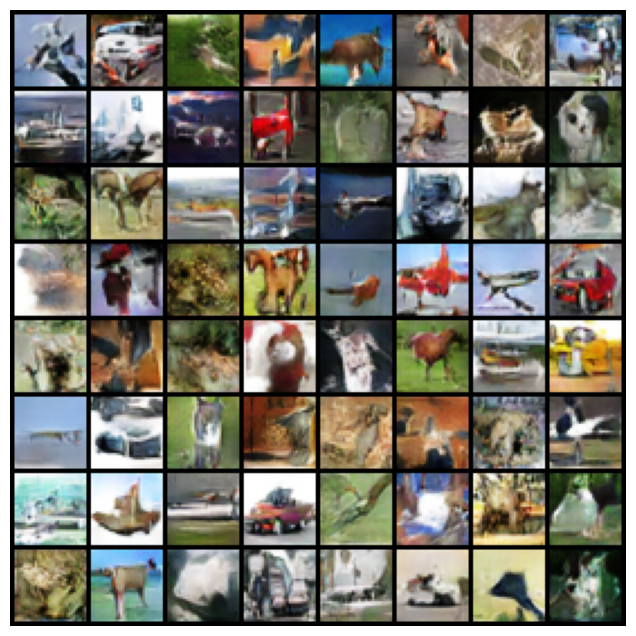

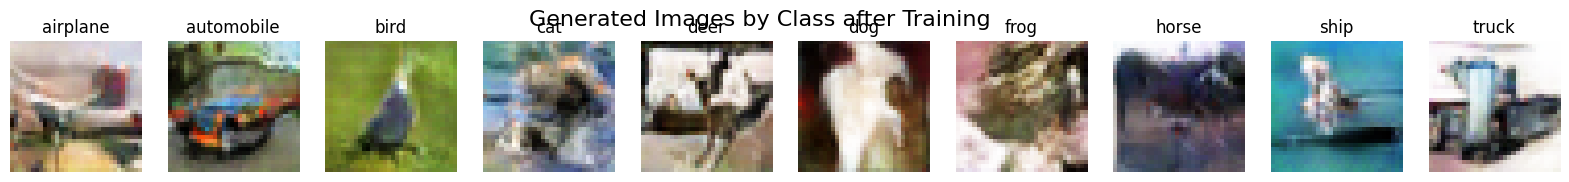

In [ ]:
img_list = []
G_losses = []
D_losses = []
iters = 0

# Create a fixed set of labels for visualization during training
# This will generate one image for each class (0 to 9)
fixed_labels_vis = torch.arange(0, num_classes, device=device).long()
# Repeat the labels to get batch_size number of samples for each class
# For example, if batch_size=64 and num_classes=10,
# it will generate 6 images for 4 classes and 7 for the rest
fixed_labels_vis = fixed_labels_vis.repeat(64 // num_classes + 1)[:64]
print(f"Fixed labels for visualization: {fixed_labels_vis.tolist()}")


print("Starting Training Loop...")2
# For each epoch
for epoch in tqdm(range(num_epochs), desc="Epochs"):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        real_labels = data[1].to(device) # Get real labels
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu, real_labels).view(-1) # Pass real labels to D
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_labels = torch.randint(0, num_classes, (b_size,), device=device).long() # Generate fake labels
        # Generate fake image batch with G
        fake = netG(noise, fake_labels) # Pass fake labels to G
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach(), fake_labels).view(-1) # Pass fake labels to D
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the real and fake batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        # (2) Update G network: maximize log(D(G(z)))
      
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        # Use the same noise and fake_labels as before for consistency in this step
        output = netD(fake, fake_labels).view(-1) # Pass fake labels to D
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise, fixed_labels_vis).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

print("Training finished.")

# Plot the losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Visualize generated images from training
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)
HTML(ani.to_jshtml())

# Generate final images for each class
print("Generating final images for each class...")
fixed_noise_per_class = torch.randn(num_classes, nz, 1, 1, device=device)
fixed_labels_per_class = torch.arange(0, num_classes, device=device).long()

with torch.no_grad():
    generated_images = netG(fixed_noise_per_class, fixed_labels_per_class).detach().cpu()

fig, axes = plt.subplots(1, num_classes, figsize=(20, 2))
for j in range(num_classes):
    ax = axes[j]
    ax.imshow(np.transpose(vutils.make_grid(generated_images[j], padding=0, normalize=True).cpu(), (1, 2, 0)))
    ax.set_title(class_names[j])
    ax.axis("off")
plt.suptitle("Generated Images by Class after Training", fontsize=16)
plt.show()